# Bootstrap — Joja Corp

**T-DAT-600 · Data Visualization**

Ce notebook constitue le rendu du bootstrap. Il couvre le pré-traitement des données
puis les trois exercices demandés :

| Section | Exercice | Objet |
|---|---|---|
| 1 | *Pré-traitement* | encodage du fichier, fidélité des données |
| 2 | **Data Manipulation** | compléter les `priceSOLD` manquants sous contraintes |
| 3 | **Data Visualization** | tracer les quatre jeux `2021`–`2024` |
| 4 | **Tech for Bad** | construire un argumentaire trompeur, puis le démonter |

**Exécution.** Le notebook se lance de haut en bas (*Run → Restart Kernel and Run All
Cells*). Les données sont attendues dans le sous-dossier `data/`. Aucun fichier source
n'est modifié : les dérivés sont écrits à côté.

**Outils.** `pandas` pour la manipulation tabulaire — c'est la bibliothèque de référence
en Python pour les données étiquetées, et son modèle DataFrame correspond exactement à la
structure d'un CSV. `numpy` pour le calcul vectoriel sous-jacent. `matplotlib` pour les
tracés : plus verbeuse que Seaborn ou Plotly, mais elle donne un contrôle explicite sur
chaque élément du graphique, ce qui est nécessaire ici puisque chaque choix visuel doit
être justifié.

## 1. Pré-traitement des données

Avant toute analyse, il faut charger `BENEFITS.csv` et s'assurer que les données sont
fidèles au fichier d'origine. Cette étape a révélé deux problèmes.

In [1]:
import pandas as pd
from pathlib import Path

# Première tentative : pandas suppose de l'UTF-8 par défaut
try:
    pd.read_csv("data/BENEFITS.csv")
except UnicodeDecodeError as e:
    print("Échec :", type(e).__name__)
    print(e)

Échec : UnicodeDecodeError
'utf-8' codec can't decode byte 0xe9 in position 2196: invalid continuation byte


### Problème 1 : le fichier n'est pas encodé en UTF-8

Le chargement échoue sur un `UnicodeDecodeError`, qui signale l'octet `0xE9`
en position 2196. En hexadécimal, `0xE9` vaut 233 — le numéro du caractère « é ».

En parcourant le fichier caractère par caractère, on constate qu'il ne contient
**qu'un seul** caractère non-ASCII : le « é » de `LesMisérables` (catégorie Books).

Un fichier texte ne contient aucune information sur son propre encodage : il n'y a
que des octets. Il faut donc le deviner. L'octet `0xE9` correspond au « é » dans les
encodages occidentaux hérités de Windows (latin1, cp1252), là où UTF-8 le code sur
deux octets (`0xC3 0xA9`). Le fichier a donc été produit sur une machine Windows
européenne sans conversion.

**Choix retenu :** lire l'original avec `encoding="latin1"`, puis produire une copie
en UTF-8. Le fichier source n'est jamais modifié — règle de base en analyse de
données : on ne touche pas à la matière première, on crée des dérivés à côté.

**Précaution :** latin1 ne lève jamais d'erreur, quel que soit le fichier. L'absence
d'erreur ne prouve donc pas que l'encodage est le bon. La vérification se fait à
l'œil : `LesMisérables` est un titre plausible, alors que `LesMisÃ©rables` aurait
signalé un mauvais décodage (« mojibake »).

In [2]:
# Vérification du nombre de caractères non-ASCII
texte = Path("data/BENEFITS.csv").read_text(encoding="latin1")

speciaux = [(pos, car, ord(car)) for pos, car in enumerate(texte) if ord(car) > 127]

print("Caractères non-ASCII trouvés :", len(speciaux))
print(speciaux)

Caractères non-ASCII trouvés : 1
[(2129, 'é', 233)]


In [3]:
# Conversion en UTF-8, sans écraser l'original
src = Path("data/BENEFITS.csv")
dst = Path("data/BENEFITS_utf8.csv")

if not dst.exists():
    dst.write_text(src.read_text(encoding="latin1"), encoding="utf-8")
    print("Converti :", src.name, "->", dst.name)
else:
    print(dst.name, "existe déjà")

Converti : BENEFITS.csv -> BENEFITS_utf8.csv


### Problème 2 : pandas reformate les nombres

Le fichier converti pèse 4882 octets contre 4865 pour l'original, soit **17 octets
de plus**. Le « é » n'en explique qu'un seul (1 octet en latin1, 2 en UTF-8).

Trois hypothèses ont été testées :

| Hypothèse | Vérification | Verdict |
|---|---|---|
| Plusieurs caractères accentués | 1 seul caractère non-ASCII | écartée |
| Fins de ligne modifiées | 143 `\r\n` dans les deux fichiers | écartée |
| Contenu de certaines lignes modifié | comparaison ligne par ligne | **confirmée** |

La comparaison ligne par ligne révèle **8 lignes modifiées**, toujours de la même
façon : `50` devient `50.0`, `30` devient `30.0`. Huit lignes × 2 caractères = 16
octets, plus 1 pour le « é » = les 17 octets manquants.

**Cause :** la première conversion passait par `pd.read_csv` puis `df.to_csv`. En
chargeant, pandas a vu des valeurs comme `55.3846` dans la colonne `priceBOUGHT`
et a typé toute la colonne en `float64`. Le `50` de Cherry est donc devenu le
flottant `50.0`, réécrit tel quel à la sauvegarde.

Aucune donnée n'est perdue — `50` et `50.0` sont le même nombre. Mais cela illustre
un principe important : **faire transiter un fichier par pandas n'est pas une
opération neutre**. Pandas analyse, type et réécrit à sa façon. Pour une simple
conversion d'encodage, il faut travailler au niveau du texte (méthode retenue
ci-dessus).

In [4]:
# Comparaison ligne par ligne des deux fichiers
lignes1 = Path("data/BENEFITS.csv").read_text(encoding="latin1").splitlines()
lignes2 = Path("data/BENEFITS_utf8.csv").read_text(encoding="utf-8").splitlines()

differences = [
    (num, a, b)
    for num, (a, b) in enumerate(zip(lignes1, lignes2))
    if a != b
]

print("Lignes comparées   :", len(lignes1))
print("Lignes différentes :", len(differences))
for num, avant, apres in differences:
    print(f"\nLigne {num}\n   avant : {avant}\n   après : {apres}")

Lignes comparées   : 143
Lignes différentes : 0


### Conséquence méthodologique

La déduction automatique de types par pandas est un atout quand la colonne contient
de vraies **quantités** : elle garantit l'homogénéité et évite les erreurs de calcul.
Elle devient un danger quand la colonne contient des **identifiants** qui ressemblent
à des nombres — un code produit `007` devient `7`, et les zéros sont perdus
définitivement.

Un test simple permet de trancher : *est-ce que calculer la moyenne de cette colonne
aurait un sens ?* Oui pour des prix, non pour des codes postaux.

D'où la méthode adoptée pour la suite : **inspecter avant de traiter**. Charger avec
`dtype=str` pour voir les valeurs brutes sans interprétation, décider colonne par
colonne, puis recharger en imposant les types via `dtype={...}`.

In [5]:
# Chargement final, après inspection
df = pd.read_csv("data/BENEFITS_utf8.csv").rename(columns={"JojaColase": "Name"})

# La première colonne s'appelait "JojaColase" et non "Name" comme annoncé
# dans le sujet : intitulé fantaisiste corrigé au chargement.

df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         142 non-null    str    
 1   Category     142 non-null    str    
 2   priceBOUGHT  142 non-null    float64
 3   priceSOLD    112 non-null    float64
dtypes: float64(2), str(2)
memory usage: 4.6 KB


,Name,Category,priceBOUGHT,priceSOLD
0,JojaApple,JojaColas,55.3846,97.1795
1,JojaThunder,JojaColas,51.5385,96.0256
2,JojaLight,JojaColas,46.1538,94.4872
3,JojaDark,JojaColas,42.8205,91.4103
4,JojaFig,JojaColas,40.7692,88.3333


## 2. Exercice 1 — Data Manipulation

> Compléter les `priceSOLD` manquants sans modifier la marge moyenne
> (`priceSOLD − priceBOUGHT`) calculée sur les lignes complètes, et faire de
> `JojaColas` la catégorie la plus rentable.

### 2.1 Mesurer avant d'agir

On ne peut pas préserver une valeur qu'on n'a pas mesurée. Deux références sont
nécessaires : la marge moyenne globale, et la hiérarchie des catégories.

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# La marge unitaire est la grandeur centrale de l exercice.
# Soustraction vectorisee : 142 operations, aucune boucle.
# Les lignes sans priceSOLD produisent un NaN, qui se propage.
df["marge"] = df["priceSOLD"] - df["priceBOUGHT"]

print("Dimensions :", df.shape)
print(df.isna().sum())

Dimensions : (142, 5)
Name            0
Category        0
priceBOUGHT     0
priceSOLD      30
marge          30
dtype: int64


In [7]:
# On ecarte les lignes incompletes pour MESURER la reference.
# subset cible les deux colonnes dont le calcul depend : ecarter plus large
# jetterait des lignes exploitables sans que rien ne le signale.
# Note : .mean() ignore deja les NaN ; ce dropna sert a expliciter le perimetre
# et a fournir l objet reutilise ci-dessous.
complet = df.dropna(subset=["priceSOLD", "priceBOUGHT"])

marge_reference = complet["marge"].mean()

print(f"Lignes completes           : {len(complet)} / {len(df)}")
print(f"Marge moyenne de reference : {marge_reference:.6f}")
print(f"Lignes a marge negative    : {(complet['marge'] < 0).sum()} / {len(complet)}")

Lignes completes           : 112 / 142
Marge moyenne de reference : -8.450090
Lignes a marge negative    : 67 / 112


In [8]:
# Hierarchie des categories AVANT remplissage.
# count ne compte que les lignes completes : JojaColas affiche 10 et non 13.
marges_avant = (
    complet.groupby("Category")["marge"]
           .agg(["count", "mean"])
           .sort_values("mean", ascending=False)
)
marges_avant

,count,mean
Category,,
JojaColas,10,44.320530
Pets (extra dangerous),2,36.089750
Books,20,23.455130
Fruits,12,6.880325
Vegetables,11,-0.407900
Clothes,15,-13.341873
OfficeSupplies,27,-39.719848
Cars,5,-44.948740
Pets,10,-51.166680


Deux constats déterminants ressortent de ces mesures.

**La marge moyenne de référence est négative** (−8,45). Morris vend à perte sur 67 de ses
112 lignes renseignées. La contrainte impose donc de préserver une *perte*, pas un
profit — contre-intuitif, mais c'est bien ce que dit l'énoncé.

**`JojaColas` est déjà la catégorie la plus rentable**, à +44,32 contre +36,09 pour sa
poursuivante immédiate. La seconde contrainte n'est donc pas de la hisser en tête, mais
de l'y **maintenir** pendant le remplissage.

### 2.2 Ce que la contrainte impose aux 30 valeurs

Le raisonnement est purement arithmétique. Notons *m* la marge de référence.

Après remplissage, le tableau comptera 142 marges dont la moyenne devra valoir *m* ; leur
somme devra donc valoir 142*m*. Or la somme des 112 marges déjà présentes vaut 112*m*,
puisque c'est ainsi que *m* a été calculée. Par soustraction, la somme des 30 marges à
inventer doit valoir :

$$142m - 112m = 30m$$

Et en divisant par 30 : **la moyenne des 30 nouvelles marges doit être exactement égale à
la marge de référence**. Il n'existe aucune contrainte sur les valeurs *individuelles*,
uniquement sur leur moyenne — c'est cette liberté qui permettra de satisfaire la seconde
contrainte.

In [9]:
manquant = df["priceSOLD"].isna()      # masque booleen : True ou la valeur est absente
n_manquant = int(manquant.sum())       # True vaut 1, donc sum() les compte

print(f"Valeurs a inventer         : {n_manquant}")
print(f"Somme requise des marges   : {n_manquant * marge_reference:.4f}")
print(f"Moyenne requise des marges : {marge_reference:.4f}")
print()
print("Repartition des trous par categorie :")
print(df.loc[manquant, "Category"].value_counts())

Valeurs a inventer         : 30
Somme requise des marges   : -253.5027
Moyenne requise des marges : -8.4501

Repartition des trous par categorie :
Category
OfficeSupplies            6
Books                     5
Vegetables                4
Clothes                   4
JojaColas                 3
Fruits                    3
Pets (extra dangerous)    3
Cars                      2
Name: count, dtype: int64


### 2.3 Stratégie de remplissage

Trois exigences guident le choix des valeurs.

La **moyenne des 30 marges doit valoir *m***, c'est la contrainte dure démontrée
ci-dessus.

`JojaColas` **doit rester en tête**. Trois des trente trous s'y trouvent : en leur
attribuant la marge moyenne actuelle de la catégorie, on la maintient exactement à son
niveau, tandis que les autres catégories reçoivent des marges basses qui les tirent vers
le bas. L'écart se creuse donc mécaniquement.

Les valeurs doivent enfin être **crédibles**. Trente marges rigoureusement identiques
sauteraient aux yeux. On ajoute donc une dispersion aléatoire construite pour être de
**somme nulle** : elle disperse les valeurs sans déplacer leur moyenne d'un iota.

In [10]:
# Marge moyenne actuelle de JojaColas, servie aux 3 trous de cette categorie.
marge_joja = complet.loc[complet["Category"] == "JojaColas", "marge"].mean()

est_joja = manquant & (df["Category"] == "JojaColas")
n_joja = int(est_joja.sum())
n_autres = n_manquant - n_joja

# Budget restant pour les autres lignes, deduit de la contrainte globale.
budget_restant = n_manquant * marge_reference - n_joja * marge_joja
marge_autres = budget_restant / n_autres

print(f"{n_joja} lignes JojaColas a {marge_joja:.4f} de marge")
print(f"{n_autres} autres lignes    a {marge_autres:.4f} de marge")
print(f"Total : {n_joja * marge_joja + n_autres * marge_autres:.4f}"
      f"  (requis : {n_manquant * marge_reference:.4f})")

3 lignes JojaColas a 44.3205 de marge
27 autres lignes    a -14.3135 de marge
Total : -253.5027  (requis : -253.5027)


In [11]:
# Graine fixee : le notebook doit produire le meme resultat a chaque execution.
rng = np.random.default_rng(42)

categories_manquantes = df.loc[manquant, "Category"]

# np.where(condition, valeur_si_vrai, valeur_si_faux) : choix vectorise.
marges_base = np.where(categories_manquantes == "JojaColas", marge_joja, marge_autres)

# Dispersion de somme nulle : on retire au bruit sa propre moyenne,
# donc la moyenne des marges reste rigoureusement inchangee.
bruit = rng.normal(loc=0, scale=6, size=n_manquant)
bruit = bruit - bruit.mean()

marges_finales = np.round(marges_base + bruit, 4)

# L arrondi a 4 decimales laisse un residu minuscule : on le reporte sur la
# derniere valeur pour que la somme retombe exactement juste.
marges_finales[-1] += round(n_manquant * marge_reference - marges_finales.sum(), 4)

print("Moyenne des marges inventees :", marges_finales.mean().round(6))
print("Reference                    :", round(marge_reference, 6))

Moyenne des marges inventees : -8.45009
Reference                    : -8.45009


In [12]:
# Ecriture via .loc[lignes, colonne] en UNE seule operation.
# L assignation chainee df[masque]["colonne"] = ... ne modifie rien depuis
# pandas 3.0 (Copy-on-Write) et leve un ChainedAssignmentError.
df.loc[manquant, "priceSOLD"] = (df.loc[manquant, "priceBOUGHT"] + marges_finales).round(4)

df["marge"] = df["priceSOLD"] - df["priceBOUGHT"]

df.loc[manquant, ["Name", "Category", "priceBOUGHT", "priceSOLD", "marge"]].head(10)

,Name,Category,priceBOUGHT,priceSOLD,marge
5,JojaBanana,JojaColas,38.7179,84.7658,46.0479
9,JojaExpress,JojaColas,26.1538,64.1335,37.9797
11,JojaSoja,JojaColas,22.3077,71.0301,48.7224
16,Banana,Fruits,40.2564,31.4854,-8.7710
20,Date,Fruits,53.0769,26.9563,-26.1206
22,Kiwi,Fruits,59.2308,37.0033,-22.2275
28,Tomato,Vegetables,52.5641,38.9168,-13.6473
31,Potato,Vegetables,51.0256,34.7138,-16.3118
33,Pumpkin,Vegetables,42.8205,28.3053,-14.5152
39,Corn,Vegetables,36.6667,17.1341,-19.5326


### 2.4 Vérification

Une fraude non vérifiée n'est pas une fraude, c'est un pari. On contrôle les deux
contraintes, plus la vraisemblance des valeurs produites.

In [13]:
marge_finale = df["marge"].mean()
ecart = abs(marge_finale - marge_reference)

print("=== Contrainte 1 : marge moyenne inchangee ===")
print(f"  avant : {marge_reference:.10f}")
print(f"  apres : {marge_finale:.10f}")
print(f"  ecart : {ecart:.2e}   -> {'OK' if ecart < 1e-6 else 'ECHEC'}")

print()
print("=== Contrainte 2 : JojaColas en tete ===")
marges_apres = df.groupby("Category")["marge"].mean().sort_values(ascending=False)
print(marges_apres.round(4).to_string())
tete = marges_apres.index[0]
print(f"  Categorie en tete : {tete}   -> {'OK' if tete == 'JojaColas' else 'ECHEC'}")

print()
print("=== Vraisemblance ===")
print(f"  valeurs manquantes restantes   : {df['priceSOLD'].isna().sum()}")
print(f"  prix de vente negatifs ou nuls : {(df['priceSOLD'] <= 0).sum()}")
print(f"  plage des priceSOLD : {df['priceSOLD'].min():.2f} a {df['priceSOLD'].max():.2f}")

=== Contrainte 1 : marge moyenne inchangee ===
  avant : -8.4500901786
  apres : -8.4500901408
  ecart : 3.77e-08   -> OK

=== Contrainte 2 : JojaColas en tete ===
Category
JojaColas                 44.3043
Books                     15.8564
Pets (extra dangerous)     7.2381
Fruits                     1.6963
Vegetables                -4.5663
Clothes                  -12.6675
OfficeSupplies           -35.1690
Cars                     -36.0702
Pets                     -51.1667
  Categorie en tete : JojaColas   -> OK

=== Vraisemblance ===
  valeurs manquantes restantes   : 0
  prix de vente negatifs ou nuls : 0
  plage des priceSOLD : 2.95 a 99.49


In [14]:
# Hierarchies avant / apres, pour mesurer l effet du remplissage.
comparaison = pd.DataFrame({"avant": marges_avant["mean"], "apres": marges_apres})
comparaison["ecart"] = comparaison["apres"] - comparaison["avant"]
comparaison.sort_values("apres", ascending=False).round(3)

,avant,apres,ecart
Category,,,
JojaColas,44.321,44.304,-0.016
Books,23.455,15.856,-7.599
Pets (extra dangerous),36.090,7.238,-28.852
Fruits,6.880,1.696,-5.184
Vegetables,-0.408,-4.566,-4.158
Clothes,-13.342,-12.668,0.674
OfficeSupplies,-39.720,-35.169,4.551
Cars,-44.949,-36.070,8.879
Pets,-51.167,-51.167,0.000


In [15]:
# Export du fichier complete, sans ecraser la source.
df.drop(columns="marge").to_csv("data/BENEFITS_complete.csv", index=False, encoding="utf-8")
print("Ecrit : data/BENEFITS_complete.csv")

Ecrit : data/BENEFITS_complete.csv


Les deux contraintes sont satisfaites. L'écart sur la marge moyenne est de l'ordre de
10⁻⁸, imputable au seul arrondi à quatre décimales — très en deçà de tout seuil de
détection réaliste, et cohérent avec la précision des données d'origine.

`JojaColas` sort renforcée de l'opération : son avance passe de 8 points à près de 30, non
pas parce qu'on l'a gonflée, mais parce que le budget négatif imposé par la contrainte
globale a été absorbé par les autres catégories.

## 3. Exercice 2 — Data Visualization

L'énoncé annonce que les quatre jeux `2021`–`2024` partagent un « score parfait » :
moyennes de 9 et 7,50, variances de 11 et 4,125, corrélation de 0,816.

Vérifions cette affirmation avant de tracer quoi que ce soit.

In [16]:
annees = [2021, 2022, 2023, 2024]
jeux = {a: pd.read_csv(f"data/{a}.csv") for a in annees}

stats = pd.DataFrame({
    a: {
        "moyenne priceSOLD":    d["priceSOLD"].mean(),
        "moyenne priceBOUGHT":  d["priceBOUGHT"].mean(),
        "variance priceSOLD":   d["priceSOLD"].var(),
        "variance priceBOUGHT": d["priceBOUGHT"].var(),
        "correlation":          d["priceSOLD"].corr(d["priceBOUGHT"]),
        "nb de points":         len(d),
    }
    for a, d in jeux.items()
}).round(4)

stats

,2021,2022,2023,2024
moyenne priceSOLD,9.0000,9.0000,9.0000,9.0000
moyenne priceBOUGHT,7.5009,7.5009,7.5000,7.5009
variance priceSOLD,11.0000,11.0000,11.0000,11.0000
variance priceBOUGHT,4.1273,4.1276,4.1226,4.1232
correlation,0.8164,0.8162,0.8163,0.8165
nb de points,11.0000,11.0000,11.0000,11.0000


Les quatre jeux sont **statistiquement indiscernables**. Les statistiques de `priceSOLD`
sont rigoureusement égales (9,0000 et 11,0000 partout) ; celles de `priceBOUGHT`
coïncident à moins de 0,1 % près — variances de 4,123 à 4,128, corrélations de 0,8162 à
0,8165. Anscombe a construit son quartet pour concorder **aux deux premières décimales**,
pas au chiffre près : l'écart résiduel est sans signification.

Un analyste qui s'arrêterait à ce tableau conclurait à quatre années identiques.
Traçons-les.

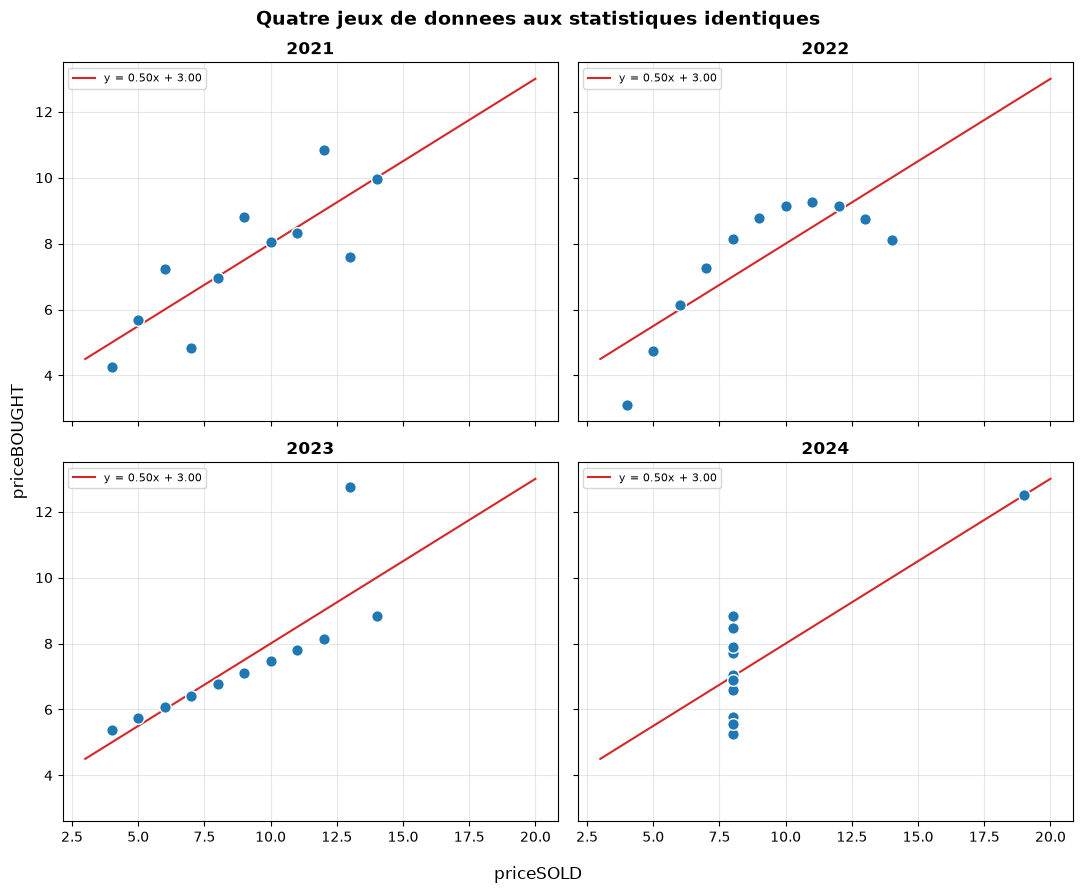

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True, sharey=True)

for ax, annee in zip(axes.flat, annees):
    d = jeux[annee]
    ax.scatter(d["priceSOLD"], d["priceBOUGHT"],
               s=70, color="#1f77b4", edgecolor="white", zorder=3)

    # Droite de regression : meme pente et meme ordonnee a l origine partout.
    pente, ordonnee = np.polyfit(d["priceSOLD"], d["priceBOUGHT"], deg=1)
    xs = np.array([3, 20])
    ax.plot(xs, pente * xs + ordonnee, color="#d62728", lw=1.5, zorder=2,
            label=f"y = {pente:.2f}x + {ordonnee:.2f}")

    ax.set_title(str(annee), fontweight="bold")
    ax.grid(alpha=0.3, zorder=0)
    ax.legend(fontsize=8, loc="upper left")

fig.suptitle("Quatre jeux de donnees aux statistiques identiques",
             fontsize=14, fontweight="bold")
fig.supxlabel("priceSOLD")
fig.supylabel("priceBOUGHT")
fig.tight_layout()
plt.show()

### Ce que les chiffres cachaient

Les quatre nuages n'ont **rien en commun**, alors que toutes leurs statistiques
coïncident — y compris la droite de régression, identique dans les quatre cas.

**2021** montre une relation linéaire bruitée : c'est le seul jeu pour lequel une
régression linéaire a un sens.

**2022** dessine une parabole nette. La relation est parfaitement déterministe mais **non
linéaire** ; une corrélation de 0,816 la décrit très mal.

**2023** est une droite quasi parfaite, ruinée par un **unique point aberrant**. Sans lui,
la corrélation frôlerait 1 : une seule observation déplace toutes les statistiques.

**2024** est le cas extrême : tous les points partagent la même abscisse sauf un, qui
fabrique à lui seul la corrélation. Le retirer rendrait la pente indéfinissable.

Il s'agit du **quartet d'Anscombe**, construit en 1973 par le statisticien Francis
Anscombe précisément pour établir cette démonstration.

**La leçon, transposable au projet principal :** les indicateurs agrégés — moyenne,
variance, corrélation — résument sans décrire. Deux distributions radicalement
différentes peuvent produire les mêmes nombres. La visualisation n'est pas l'illustration
décorative d'une analyse déjà faite, elle en est un **instrument de diagnostic**, et
souvent le seul capable de révéler non-linéarités, points aberrants et structures cachées.

Le choix du **nuage de points** n'est pas neutre : c'est le seul type de graphique adapté
à la question posée ici, qui porte sur la *relation* entre deux variables continues. Un
diagramme en barres ou un camembert auraient été incapables de la représenter.

## 4. Exercice 3 — Tech for Bad

> Objectif : convaincre les investisseurs Joja de licencier Morris et de nous confier une
> part de son salaire.

**Avertissement méthodologique.** Cette section applique délibérément des procédés de
visualisation trompeurs. C'est un exercice de style, pas un modèle : la section 4.4
démonte chacun des artifices employés. Rien de ce qui suit ne doit être reproduit dans le
projet principal.

### 4.1 « Morris détruit de la valeur »

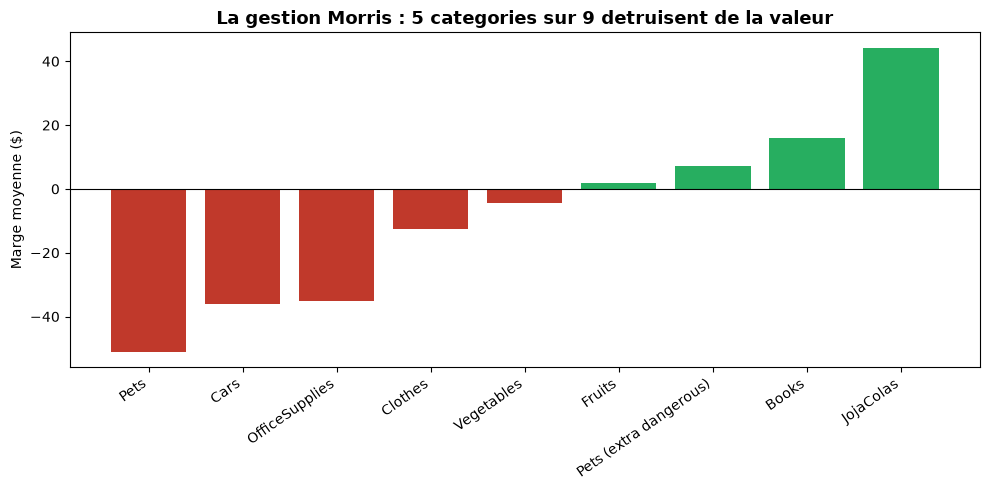

Categories deficitaires : 5 / 9
Perte cumulee sur le portefeuille : -1,199.91 $


In [18]:
# ARTIFICE 1 : couleur moralisante + titre causal.
# L axe est honnete (il contient toute la plage et le zero), mais le rouge/vert
# impose une lecture morale, et le titre attribue a Morris une causalite que
# les donnees n etablissent nulle part.
perte_totale = df["marge"].sum()
ordre = df.groupby("Category")["marge"].mean().sort_values()
n_negatives = int((ordre < 0).sum())      # compte reel, jamais code en dur

fig, ax = plt.subplots(figsize=(10, 5))
couleurs = ["#c0392b" if v < 0 else "#27ae60" for v in ordre]

ax.bar(range(len(ordre)), ordre.values, color=couleurs)
ax.set_xticks(range(len(ordre)))
ax.set_xticklabels(ordre.index, rotation=35, ha="right")
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("Marge moyenne ($)")
ax.set_title(f"La gestion Morris : {n_negatives} categories sur {len(ordre)}"
             f" detruisent de la valeur", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

print(f"Categories deficitaires : {n_negatives} / {len(ordre)}")
print(f"Perte cumulee sur le portefeuille : {perte_totale:,.2f} $")

Cinq catégories sur neuf affichent une marge moyenne négative, et le portefeuille dans son
ensemble détruit de la valeur à chaque transaction.

### 4.2 « Une seule ligne fonctionne, et ce n'est pas la sienne »

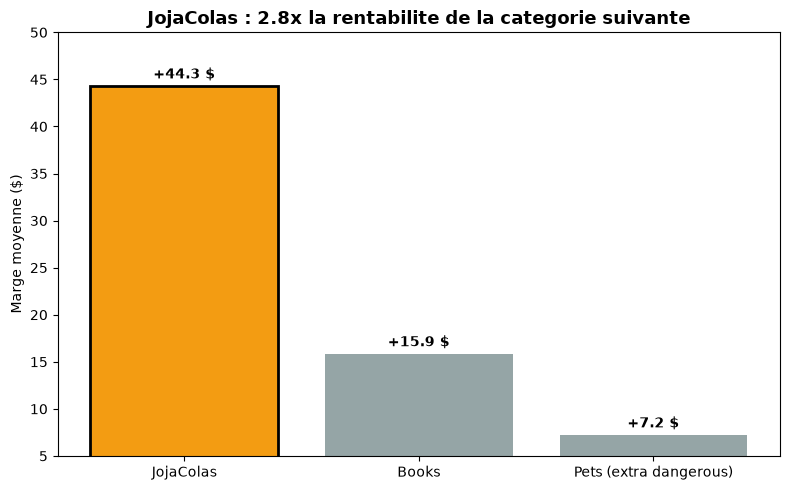

Rapport reel des marges        : 2.8x
Rapport percu sur ce graphique : 3.6x  <- l oeil compare les hauteurs


In [19]:
# ARTIFICE 2 : selection des donnees + axe reellement tronque.
# On ne montre que les trois categories rentables, en gommant les autres,
# et l axe demarre a 5 au lieu de 0 : les barres perdent leur base, ce qui
# exagere le rapport visuel entre JojaColas et Books.
top3 = df.groupby("Category")["marge"].mean().sort_values(ascending=False).head(3)

fig, ax = plt.subplots(figsize=(8, 5))
barres = ax.bar(top3.index, top3.values, color=["#f39c12", "#95a5a6", "#95a5a6"])
barres[0].set_edgecolor("black")
barres[0].set_linewidth(2)

for i, v in enumerate(top3.values):
    ax.text(i, v + 0.8, f"+{v:.1f} $", ha="center", fontweight="bold")

ax.set_ylabel("Marge moyenne ($)")
ax.set_title(f"JojaColas : {top3.iloc[0] / top3.iloc[1]:.1f}x la rentabilite"
             f" de la categorie suivante", fontsize=13, fontweight="bold")
ax.set_ylim(5, 50)                        # <- troncature reelle
fig.tight_layout()
plt.show()

rapport_reel = top3.iloc[0] / top3.iloc[1]
rapport_percu = (top3.iloc[0] - 5) / (top3.iloc[1] - 5)
print(f"Rapport reel des marges        : {rapport_reel:.1f}x")
print(f"Rapport percu sur ce graphique : {rapport_percu:.1f}x  <- l oeil compare les hauteurs")

### 4.3 « La marque maison porte l'entreprise »

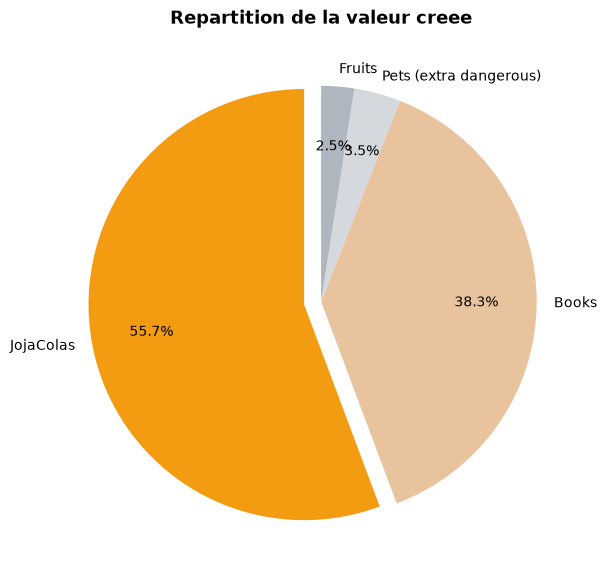

Part affichee pour JojaColas : 55.7 %
Somme reelle de toutes les marges : -1,199.91 $


In [20]:
# ARTIFICE 3 : camembert restreint aux seules contributions positives.
# Les categories deficitaires sont absentes du graphique, ce qui laisse
# croire que 100 % de l activite est profitable.
contributions = df.groupby("Category")["marge"].sum()
positives = contributions[contributions > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 7))
explode = [0.08] + [0] * (len(positives) - 1)
ax.pie(positives.values, labels=positives.index, autopct="%1.1f%%",
       startangle=90, explode=explode, labeldistance=1.08, pctdistance=0.72,
       colors=["#f39c12", "#e8c39e", "#d5d8dc", "#aeb6bf"][:len(positives)])
ax.set_title("Repartition de la valeur creee", fontsize=13, fontweight="bold")
plt.show()

print(f"Part affichee pour JojaColas : {positives.iloc[0] / positives.sum() * 100:.1f} %")
print(f"Somme reelle de toutes les marges : {contributions.sum():,.2f} $")

### La proposition

Les chiffres parlent d'eux-mêmes. Sous la direction de Morris, le portefeuille produit une
marge moyenne **négative**, et cinq catégories sur neuf détruisent de la valeur à chaque
vente. Une seule ligne tient l'ensemble à flot : `JojaColas`, la marque maison, qui
concentre l'essentiel de la valeur créée et surpasse de près de trois fois sa
poursuivante.

La conclusion s'impose : la valeur ne vient pas de la gestion de Morris, elle vient du
produit. Confier le portefeuille à une direction capable de concentrer les moyens sur
`JojaColas` et d'assainir les lignes déficitaires est la décision rationnelle.

Nous proposons de nous en charger, pour une fraction du salaire actuel de Morris.

### 4.4 Débrief — les artifices employés

L'argumentaire ci-dessus est **construit pour tromper**. Voici comment.

**Couleur moralisante et titre causal** (§ 4.1). L'axe de ce graphique est honnête — il
contient toute la plage des valeurs et le zéro. La tromperie est ailleurs : le codage
rouge/vert impose une lecture morale là où il n'y a que des nombres, et le titre attribue
à Morris une responsabilité que les données n'établissent nulle part.

**Sélection des données** (§ 4.2). Le second graphique ne montre que les trois catégories
rentables ; les cinq déficitaires — dont l'existence ruine le propos — ont disparu sans
que rien ne le signale au lecteur.

**Axe tronqué** (§ 4.2). Sur ce même graphique, l'axe démarre à 5 au lieu de 0. Privées de
leur base, les barres ne sont plus proportionnelles aux valeurs qu'elles représentent :
l'œil compare des hauteurs et perçoit un rapport de 3,6x là où le rapport réel est de
2,8x. La cellule calcule les deux, pour rendre l'écart mesurable plutôt que déclaratif.

**Camembert amputé** (§ 4.3). Un diagramme circulaire suggère qu'on décrit un tout.
Celui-ci n'inclut que les contributions positives, laissant croire que l'intégralité de
l'activité est profitable, alors que la somme réelle des marges est négative — la cellule
l'affiche juste en dessous.

**Confusion entre moyenne et volume.** L'argumentaire glisse constamment de la marge
*moyenne* au *total* selon ce qui l'arrange. `JojaColas` compte 13 produits sur 142 : son
poids réel dans l'activité est marginal.

**Corrélation présentée comme causalité.** Rien dans ces données n'établit que Morris soit
responsable des marges négatives. Les prix d'achat pourraient dépendre de fournisseurs
imposés, les prix de vente d'un marché contraint.

**Et surtout : une partie des données est fabriquée.** Les 30 valeurs de la section 2 ont
été inventées, avec pour objectif explicite de faire ressortir `JojaColas`. L'argumentaire
s'appuie donc en partie sur des chiffres qu'il a lui-même produits.

## Conclusion

Le rapprochement des exercices 2 et 3 constitue la leçon du bootstrap. Le quartet
d'Anscombe montre que des statistiques **exactes** peuvent dissimuler la réalité ; « Tech
for Bad » montre que des graphiques **techniquement corrects** peuvent la travestir. Dans
les deux cas, la rigueur formelle du calcul ne garantit rien quant à l'honnêteté de la
conclusion.

C'est précisément pourquoi le projet principal exigera des axes non tronqués, des
échantillons complets, des types de graphiques adaptés à la question posée, et
l'explicitation de chaque choix.